# 👋 Welcome to the Conformal Risk Control tutorial

In this tutorial, we use **PUNCC** to control the fraction of true labels missed by a multilabel classifier using [Conformal Risk Control](https://arxiv.org/pdf/2208.02814). Each example can have several labels, so a prediction can be partly correct. By the end, you will be able to define a bounded loss, wrap a model with `CRC`, and evaluate the trade-off between missed labels and prediction set size.

**Table of contents**

- [📊 From coverage to risk control](#intro)
- [🛠️ Backend configuration](#setup)
- [💾 Multilabel dataset](#data)
- [🔮 Prediction model](#model)
- [⚙️ Conformal Risk Control](#crc)
- [📏 Evaluation and visualization](#evaluation)
- [🔄 Repeated calibration experiment](#repetition)
- [🎉 Going further](#conclusion)

**Links**

- [GitHub](https://github.com/deel-ai/puncc)
- [📘 Documentation](https://deel-ai.github.io/puncc/index.html)
- [Angelopoulos et al., Conformal Risk Control](https://arxiv.org/pdf/2208.02814)

## 📊 From coverage to risk control <a class="anchor" id="intro"></a>

Ordinary conformal prediction controls a binary error: whether the true outcome is outside a prediction set. **Conformal Risk Control (CRC)** generalizes this idea to bounded losses that decrease as predictions become more conservative.

In this tutorial we illustrate how to use the CRC algorithm with PUNCC, on a multilabel classification problem: given a total of $K$ possible labels, each covariate is associated to a set of labels $y\subseteq\lbrace 1,\dots, K\rbrace$.

Given a covariate $X$ and its associated label set $Y$, we wish to control how well a model outputting predictions $C(X)\subseteq\lbrace1,\dots,K\rbrace$ does. We could use conformal prediction to control the binary loss $1_{Y\not\subseteq C(X)}$, however, this loss penalizes all errors equally: missing to predict a single label from $Y$ is as bad as missing many labels from $Y$. A more informative loss is the **per-example false-negative loss**, which couts the proportion of true labels missed by the prediction set, i.e. 

$$L(C,Y)=\frac{|Y\setminus C|}{|Y|}.$$

For example, missing one of three true labels incurs loss of $1/3$ whilst missing all three true labels incurs a loss of $1$. For an empty true set, we define the loss as zero (our dataset excludes this case). This loss satisfies the **monotonicity** assumption of CRC : for a fixed true set $Y$, the loss decreases as the set $C$ grows. It is equally **bounded** by 1.

Given a model that outputs per label scores $p_k(x)\in[0,1], k\in\lbrace 1,\dots,K\rbrace$, define

$$C_\lambda(x)=\{k:p_k(x)\geq 1-\lambda\},\qquad \lambda\in[0,1].$$

Increasing $\lambda$ includes more labels, so that for a fixed example the loss function is non-increasing in $\lambda$ and bounded by $B=1$. The non-strict threshold makes the loss right-continuous. At $\lambda=1$, every label is included and the loss is 0.

For $n$ calibration examples, the empirical risk is defined as 
$$\widehat R_n(\lambda)=\frac1n\sum_{i=1}^n L(C_\lambda(X_i),Y_i).$$

CRC chooses the smallest feasible parameter as follows

$$\widehat \lambda = \inf \Big\lbrace \lambda \in [0,1] : \frac{n}{n+1}\widehat R_n(\lambda)+\frac{B}{n+1}\leq\alpha\Big\rbrace.$$

Under the paper's assumptions, including exchangeability of calibration and test examples and a model fitted independently of them, the guarantee is $\mathbb E[L(C_{\widehat\lambda}(X_{new}),Y_{new})]\leq\alpha$. The expectation includes calibration and test randomness. It is **not** a guarantee for every example, label, or realized test-set average, nor a high-probability guarantee conditional on one calibration set. A calibration set can be reused for multiple predictions.

See [the paper, Sections 1–2](https://arxiv.org/pdf/2208.02814) for the precise assumptions and theorem.

## 🛠️ Backend configuration <a class="anchor" id="setup"></a>

Use a Python environment with this version of PUNCC, NumPy, SciPy, scikit-learn, Matplotlib, and a Jupyter kernel installed. This PUNCC version uses Keras >= 3.3 for its NumPy operations; the Keras NumPy backend also imports JAX. If these backend dependencies are missing, install them in the notebook environment with `%pip install "keras>=3.3" jax` and restart the kernel.

No dataset download or GPU is needed. Select the NumPy backend before constructing the predictor. Run the cells in order.

In [78]:
from deel.puncc.config import set_backend
set_backend("numpy")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_multilabel_classification
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from deel.puncc.core.risk_control import CRC

SEED = 13

## 💾 Multilabel dataset <a class="anchor" id="data"></a>

We generate 5,000 examples with 20 features, 5 possible labels, and label sets of 2 labels in average per example, using scikit-learn's [make_multilabel_classification](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_multilabel_classification.html). The generator produces a synthetic document-like classification problem with count features. Multiple labels per example make partial errors easy to see, and synthetic data keep the tutorial reproducible and lightweight.

Generate the dataset once, then randomly split it into **60% fit, 20% calibration, and 20% test**. All subsets thus share the same generating mechanism. The fit subset is used for learning both preprocessing and model parameters; calibration chooses the CRC threshold; test data are reserved for evaluation. We do not select hyperparameters using calibration or test outcomes.

Fit         : X (3000, 20), Y (3000, 5)
Calibration : X (1000, 20), Y (1000, 5)
Test        : X (1000, 20), Y (1000, 5)


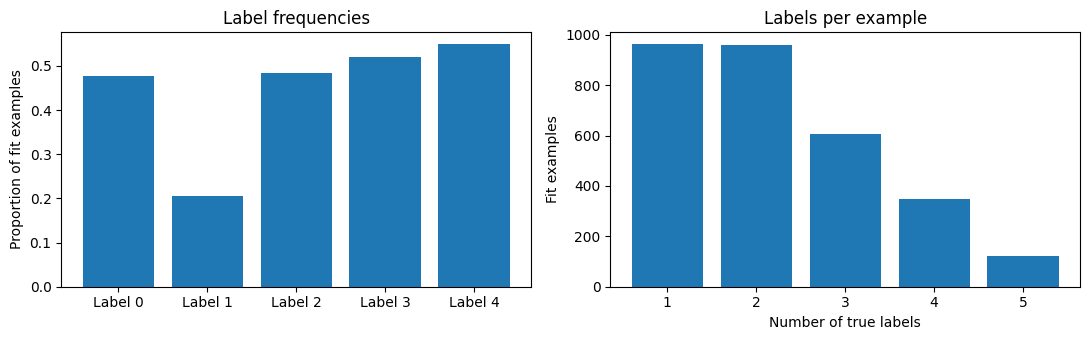

In [79]:
X, Y = make_multilabel_classification(
    n_samples=5000, n_features=20, n_classes=5, n_labels=2,
    allow_unlabeled=False, return_indicator="dense", random_state=SEED,
)
Y = Y.astype(bool)
X_fit, X_holdout, Y_fit, Y_holdout = train_test_split(
    X, Y, test_size=0.4, random_state=SEED,
)
X_calib, X_test, Y_calib, Y_test = train_test_split(
    X_holdout, Y_holdout, test_size=0.5, random_state=SEED + 1,
)
label_names = np.array([f"Label {k}" for k in range(Y.shape[1])])
for name, features, targets in [
    ("Fit", X_fit, Y_fit), ("Calibration", X_calib, Y_calib),
    ("Test", X_test, Y_test),
]:
    print(f"{name:12s}: X {features.shape}, Y {targets.shape}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].bar(label_names, Y_fit.mean(axis=0))
axes[0].set(ylabel="Proportion of fit examples", title="Label frequencies")
counts = Y_fit.sum(axis=1)
axes[1].bar(np.arange(1, 6), [(counts == k).sum() for k in range(1, 6)])
axes[1].set(xlabel="Number of true labels", ylabel="Fit examples",
            title="Labels per example", xticks=np.arange(1, 6))
plt.tight_layout()
plt.show()

## 🔮 Prediction model <a class="anchor" id="model"></a>

We use one logistic regression classifier per label. A pipeline fits feature scaling on the fit subset only. The `ProbabilityPredictor` adapter is designed to make our model compatible with PUNCC: it exposes `fit` and makes `predict` return a probability matrix of shape `(n_examples, n_labels)`, rather than hard classifications. Multilabel scores need not sum to one across labels.

We construct the model here and train it through `CRC.fit` in the next section. The baseline will include labels whose probabilities are at least 0.5.

In [80]:
class ProbabilityPredictor:
    """Expose per-label probabilities through PUNCC's predict interface."""

    def __init__(self, estimator):
        self.estimator = estimator

    def fit(self, X, Y):
        self.estimator.fit(X, Y)
        return self

    def predict(self, X):
        return self.estimator.predict_proba(X)


model = ProbabilityPredictor(make_pipeline(
    StandardScaler(),
    OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=SEED)),
))

## ⚙️ Conformal Risk Control <a class="anchor" id="crc"></a>

CRC needs two functions: a **postprocessor** or **family of set predictors** $C_\lambda(x)$ that turns scores and a scalar parameter into predictions, and a **loss function** $L(C_\lambda(X),Y)$ returning one bounded loss per example. Here prediction sets are Boolean vectors in $\lbrace \mathtt{True}, \mathtt{False}\rbrace^K$, with `True` meaning that the corresponding index is included in the prediction set.

In [81]:
def label_sets(probabilities, lambd):
    """Include more labels as lambd increases from 0 to 1."""
    return np.asarray(probabilities) >= 1.0 - lambd


def false_negative_loss(prediction_sets, targets):
    """Fraction of true labels missed, separately for each example."""
    targets = np.asarray(targets, dtype=bool)
    prediction_sets = np.asarray(prediction_sets, dtype=bool)
    missed = (targets & ~prediction_sets).sum(axis=1)
    total = targets.sum(axis=1)
    return np.divide(missed, total, out=np.zeros(len(total), dtype=float),
                     where=total > 0)


# A small example: one of three labels is missed; an empty target has loss 0.
example_targets = np.array([[1, 1, 1, 0, 0], [0, 0, 0, 0, 0]])
example_sets = np.array([[1, 0, 1, 0, 0], [1, 0, 0, 0, 0]])
print("Example losses:", false_negative_loss(example_sets, example_targets))

Example losses: [0.33333333 0.        ]


Set `alpha=0.1` to target at most 10% missed true labels in expectation. We explicitly pass the loss upper bound, `B=1`. The default binary search finds a feasible parameter to numerical tolerance within `(0, 1)`.

The method `calibrate` computes and stores calibration predictions and targets. The alpha-dependent threshold is computed when `predict` is called and cached for subsequent use with that alpha. Finally, `predict` returns both raw model probabilities and the Boolean prediction sets.

In [82]:
alpha = 0.1
crc = CRC(
    model=model,
    postprocessor=label_sets,
    loss_function=false_negative_loss,
    loss_function_upper_bound=1.0,
    lambda_bounds=(0.0, 1.0),
    search_tol=1e-5,
    max_iter=25,
)
crc.fit(X_fit, Y_fit)
crc.calibrate(X_calib, Y_calib)
probabilities, crc_sets = crc.predict(X_test, alpha=alpha)
baseline_sets = probabilities >= 0.5

print(f"Calibrated with {crc.len_calib} examples; target risk = {alpha:.0%}")

Calibrated with 1000 examples; target risk = 10%


## 📏 Evaluation and visualization <a class="anchor" id="evaluation"></a>

Compare the fixed 0.5 threshold with CRC on the untouched test subset. Smaller loss means fewer missed true labels; smaller sets mean fewer returned labels. CRC controls the former, while model quality affects how large sets need to be. It does not directly control false positives or precision.

Method                 Mean missed fraction    Mean set size
Fixed threshold 0.5                  0.1507             2.06
CRC                                  0.1016             2.45


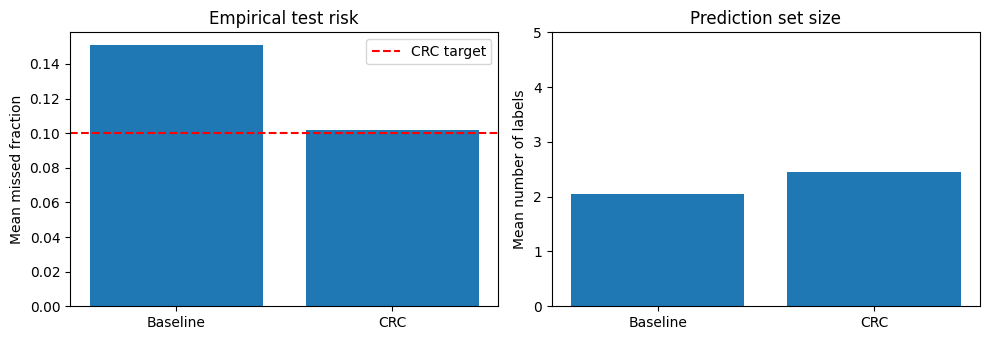

Example 0
  True:     ['Label 0', 'Label 4']
  Baseline: ['Label 0', 'Label 3', 'Label 4']
  CRC:      ['Label 0', 'Label 3', 'Label 4']
Example 1
  True:     ['Label 3']
  Baseline: ['Label 3']
  CRC:      ['Label 1', 'Label 3']
Example 2
  True:     ['Label 2']
  Baseline: ['Label 2']
  CRC:      ['Label 2']
Example 3
  True:     ['Label 0', 'Label 3']
  Baseline: ['Label 0', 'Label 3']
  CRC:      ['Label 0', 'Label 3']
Example 4
  True:     ['Label 0', 'Label 2', 'Label 4']
  Baseline: ['Label 0', 'Label 2', 'Label 4']
  CRC:      ['Label 0', 'Label 2', 'Label 4']


In [83]:
def evaluate(sets, targets):
    return false_negative_loss(sets, targets).mean(), sets.sum(axis=1).mean()


baseline_risk, baseline_size = evaluate(baseline_sets, Y_test)
crc_risk, crc_size = evaluate(crc_sets, Y_test)
print(f"{'Method':<20} {'Mean missed fraction':>22} {'Mean set size':>16}")
for name, risk, size in [
    ("Fixed threshold 0.5", baseline_risk, baseline_size),
    ("CRC", crc_risk, crc_size),
]:
    print(f"{name:<20} {risk:>22.4f} {size:>16.2f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].bar(["Baseline", "CRC"], [baseline_risk, crc_risk])
axes[0].axhline(alpha, color="red", linestyle="--", label="CRC target")
axes[0].set(ylabel="Mean missed fraction", title="Empirical test risk")
axes[0].legend()
axes[1].bar(["Baseline", "CRC"], [baseline_size, crc_size])
axes[1].set(ylabel="Mean number of labels", title="Prediction set size", ylim=(0, 5))
plt.tight_layout()
plt.show()

for i in range(5):
    k = np.random.randint(0, len(Y_test) - 1)
    print(f"Example {i}")
    print("  True:    ", label_names[Y_test[k]].tolist())
    print("  Baseline:", label_names[baseline_sets[k]].tolist())
    print("  CRC:     ", label_names[crc_sets[k]].tolist())

With the fixed seed used here, CRC reduces the test missed-label fraction from approximately **15.1% to 10.2%**, while increasing mean set size from **2.06 to 2.45** labels. The observed CRC test risk is slightly above the 10% target even though its corrected calibration risk is below that target. This is compatible with a guarantee in expectation over calibration and test randomness. We keep this split rather than searching for a seed that produces a more favorable result; the repeated-calibration section below explores that variability.

### Changing the requested risk level

Keep the same fitted model and calibration set, and evaluate several **predetermined** risk targets. Lower alpha calls for more conservative predictions. These plots describe the trade-off; we do not use test results to choose alpha. The theorem applies to each fixed alpha and does not automatically justify adaptive selection after inspecting test losses.

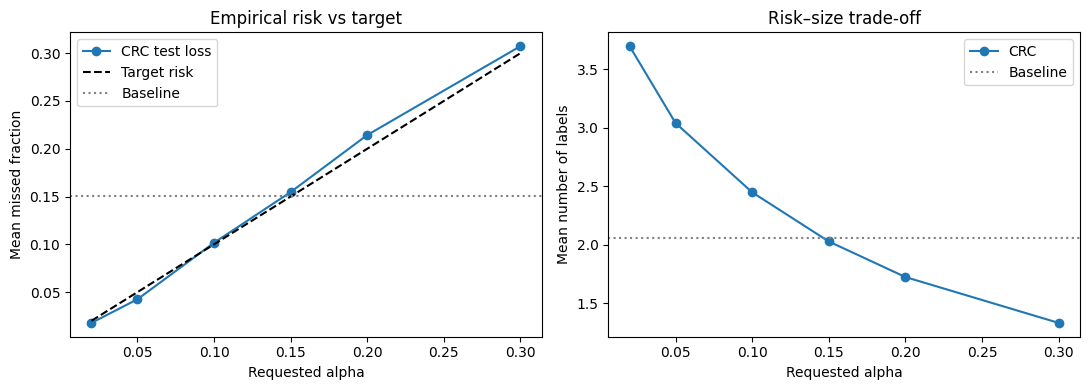

In [84]:
alpha_values = np.array([0.02, 0.05, 0.10, 0.15, 0.20, 0.30])
sweep = np.array([
    evaluate(crc.predict(X_test, alpha=float(value)).prediction_set, Y_test)
    for value in alpha_values
])
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(alpha_values, sweep[:, 0], "o-", label="CRC test loss")
axes[0].plot(alpha_values, alpha_values, "k--", label="Target risk")
axes[0].axhline(baseline_risk, color="gray", linestyle=":", label="Baseline")
axes[0].set(xlabel="Requested alpha", ylabel="Mean missed fraction",
            title="Empirical risk vs target")
axes[0].legend()
axes[1].plot(alpha_values, sweep[:, 1], "o-", label="CRC")
axes[1].axhline(baseline_size, color="gray", linestyle=":", label="Baseline")
axes[1].set(xlabel="Requested alpha", ylabel="Mean number of labels",
            title="Risk–size trade-off")
axes[1].legend()
plt.tight_layout()
plt.show()

## 🔄 Repeated calibration experiment <a class="anchor" id="repetition"></a>

This optional experiment holds the model fixed and randomly generates new calibration and test subsets 200 times. Each repetition uses disjoint calibration/test examples and a fresh CRC instance, without retraining or changing model parameters. We use a separate instance to preserve the original calibration.

This illustrates sensitivity to the calibration sample. Because the calibration set is finite and the $\widehat\lambda$ used to build the prediction set is computed from the empirical risk on the calibration set, it will be subject to random fluctuations, as shown in the below histogram.

Mean test risk across repeats: 0.0988 (target 0.10)
Standard deviation across repeats: 0.0107
Mean set size across repeats: 4.47
Repeats with test risk above alpha: 86/200


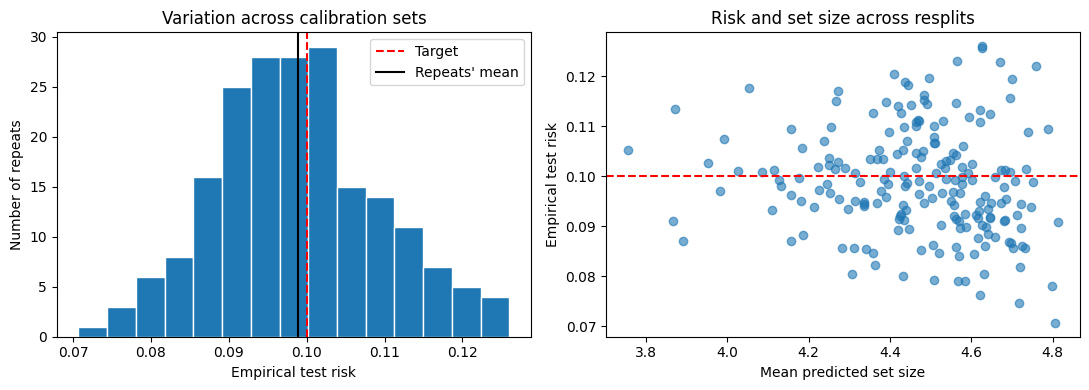

In [87]:
SEED = 31
n_repeats = 200  # Reduce for a quicker run, or skip this section.
repeat_results = []
for _ in range(n_repeats):
    SEED += 1
    X, Y = make_multilabel_classification(
        n_samples=2000, n_features=20, n_classes=5, n_labels=2,
        allow_unlabeled=False, return_indicator="dense", random_state=SEED,
    )
    Y = Y.astype(bool)
    X_calib, X_test, Y_calib, Y_test = train_test_split(
        X, Y, test_size=0.5, random_state=SEED,
    )
    
    repeat_crc = CRC(
        model=model, postprocessor=label_sets,
        loss_function=false_negative_loss, loss_function_upper_bound=1.0,
        lambda_bounds=(0.0, 1.0), search_tol=1e-5, max_iter=25,
    )
    repeat_crc.calibrate(X_calib, Y_calib)
    _, repeat_sets = repeat_crc.predict(X_test, alpha=alpha)
    repeat_results.append(evaluate(repeat_sets, Y_test))
repeat_results = np.asarray(repeat_results)
risks, sizes = repeat_results.T
print(f"Mean test risk across repeats: {risks.mean():.4f} (target {alpha:.2f})")
print(f"Standard deviation across repeats: {risks.std(ddof=1):.4f}")
print(f"Mean set size across repeats: {sizes.mean():.2f}")
print(f"Repeats with test risk above alpha: {(risks > alpha).sum()}/{n_repeats}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(risks, bins=15, edgecolor="white")
axes[0].axvline(alpha, color="red", linestyle="--", label="Target")
axes[0].axvline(risks.mean(), color="black", label="Repeats' mean")
axes[0].set(xlabel="Empirical test risk", ylabel="Number of repeats",
            title="Variation across calibration sets")
axes[0].legend()
axes[1].scatter(sizes, risks, alpha=0.6)
axes[1].axhline(alpha, color="red", linestyle="--")
axes[1].set(xlabel="Mean predicted set size", ylabel="Empirical test risk",
            title="Risk and set size across resplits")
plt.tight_layout()
plt.show()

## 🎉 Going further <a class="anchor" id="conclusion"></a>

You have used PUNCC's `CRC` to fit a multilabel classifier, calibrate it so that it has finite-sample controlled risk, and evaluate missed-label risk and prediction set size.

To adapt this example:

- **Replace the dataset:** encode targets as a Boolean matrix with one column per label, and keep fitting separate from calibration and evaluation. Consider whether calibration and deployment examples are exchangeable.
- **Replace the model:** expose per-label scores in `[0, 1]` through `predict`. Accurate probability calibration is not required by CRC's theorem, although better scores can improve efficiency.
- **Replace the loss:** return one loss per example, supply a valid upper bound, and verify that loss decreases as the parameter increases. Also check right-continuity and a safe upper parameter bound. Precision and F1 losses are not generally monotone under this threshold rule and cannot simply be substituted.
- **Choose the risk target in advance:** smaller alpha usually means larger prediction sets. A small empirical loss on one split is an observation, not a proof of the guarantee.

**Further reading**

- [Conformal Risk Control — paper](https://arxiv.org/pdf/2208.02814)
- [CRC implementation](../deel/puncc/core/risk_control.py)
- [PUNCC API tutorial](api_intro.ipynb)
- [Introduction to conformal classification](puncc_intro_classification.ipynb)